In [27]:
# Predicting Car Prices Using Data Analytics and Machine Learning

## Fundamentals of Data Analytics

### MSc Data Analytics

####Student Name: Challagolla Venkata Vikram

#####Date: June 2026

In [28]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


In [30]:
# Load dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv"

df = pd.read_csv(url, header=None)

# Assign column headers
headers = [
    "symboling","normalized-losses","make","fuel-type","aspiration",
    "num-of-doors","body-style","drive-wheels","engine-location",
    "wheel-base","length","width","height","curb-weight","engine-type",
    "num-of-cylinders","engine-size","fuel-system","bore","stroke",
    "compression-ratio","horsepower","peak-rpm","city-mpg",
    "highway-mpg","price"
]

df.columns = headers

In [31]:
# Display dataset dimensions
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(205, 26)


In [32]:
# Display first 10 rows
df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


In [33]:
# Calculate mean values
df.replace("?", np.nan, inplace=True)

numeric_cols = [
    "normalized-losses",
    "bore",
    "stroke",
    "horsepower",
    "peak-rpm",
    "price"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

df.mean(numeric_only=True)

symboling                0.834146
normalized-losses      122.000000
wheel-base              98.756585
length                 174.049268
width                   65.907805
height                  53.724878
curb-weight           2555.565854
engine-size            126.907317
bore                     3.329751
stroke                   3.255423
compression-ratio       10.142537
horsepower             104.256158
peak-rpm              5125.369458
city-mpg                25.219512
highway-mpg             30.751220
price                13207.129353
dtype: float64

In [34]:
# Calculate median values
df.median(numeric_only=True)

symboling                1.00
normalized-losses      115.00
wheel-base              97.00
length                 173.20
width                   65.50
height                  54.10
curb-weight           2414.00
engine-size            120.00
bore                     3.31
stroke                   3.29
compression-ratio        9.00
horsepower              95.00
peak-rpm              5200.00
city-mpg                24.00
highway-mpg             30.00
price                10295.00
dtype: float64

In [35]:
# Display data types
df.dtypes

symboling              int64
normalized-losses    float64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object

In [51]:
# Display unique values for categorical columns
categorical_cols = df.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


make
<StringArray>
[  'alfa-romero',          'audi',           'bmw',     'chevrolet',
         'dodge',         'honda',         'isuzu',        'jaguar',
         'mazda', 'mercedes-benz',       'mercury',    'mitsubishi',
        'nissan',        'peugot',      'plymouth',       'porsche',
       'renault',          'saab',        'subaru',        'toyota',
    'volkswagen',         'volvo']
Length: 22, dtype: str

fuel-type
<StringArray>
['gas', 'diesel']
Length: 2, dtype: str

aspiration
<StringArray>
['std', 'turbo']
Length: 2, dtype: str

num-of-doors
<StringArray>
['two', 'four']
Length: 2, dtype: str

body-style
<StringArray>
['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop']
Length: 5, dtype: str

drive-wheels
<StringArray>
['rwd', 'fwd', '4wd']
Length: 3, dtype: str

engine-location
<StringArray>
['front', 'rear']
Length: 2, dtype: str

engine-type
<StringArray>
['dohc', 'ohcv', 'ohc', 'l', 'rotor', 'ohcf']
Length: 6, dtype: str

num-of-cylinders
<StringArray>
['fou

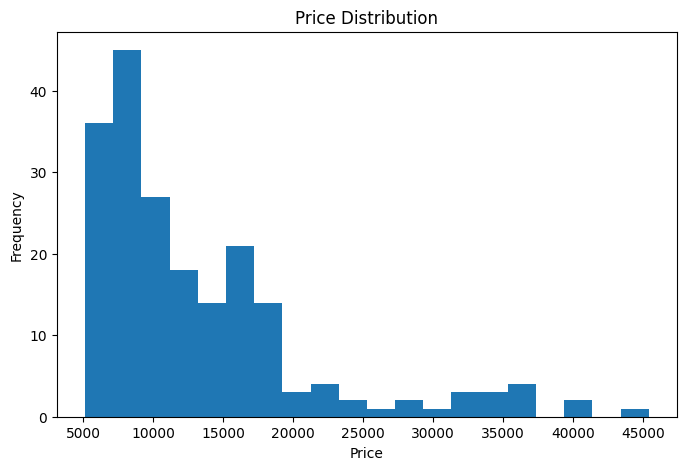

In [37]:
# Plot price distribution
plt.figure(figsize=(8,5))

plt.hist(df["price"].dropna(), bins=20)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

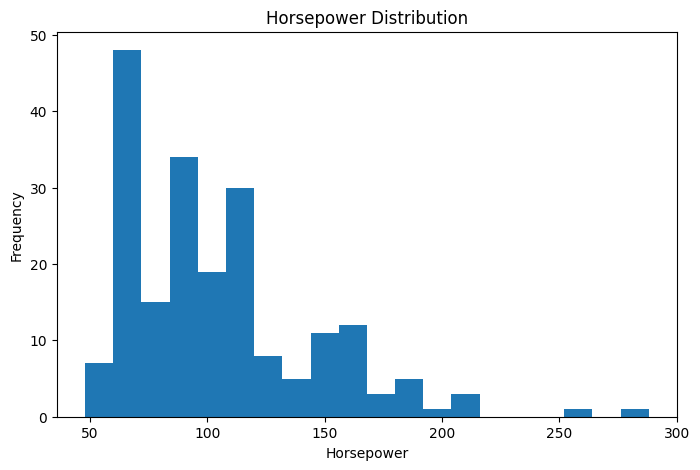

In [38]:
# Plot horsepower distribution
plt.figure(figsize=(8,5))

plt.hist(df["horsepower"].dropna(), bins=20)

plt.title("Horsepower Distribution")
plt.xlabel("Horsepower")
plt.ylabel("Frequency")

plt.show()

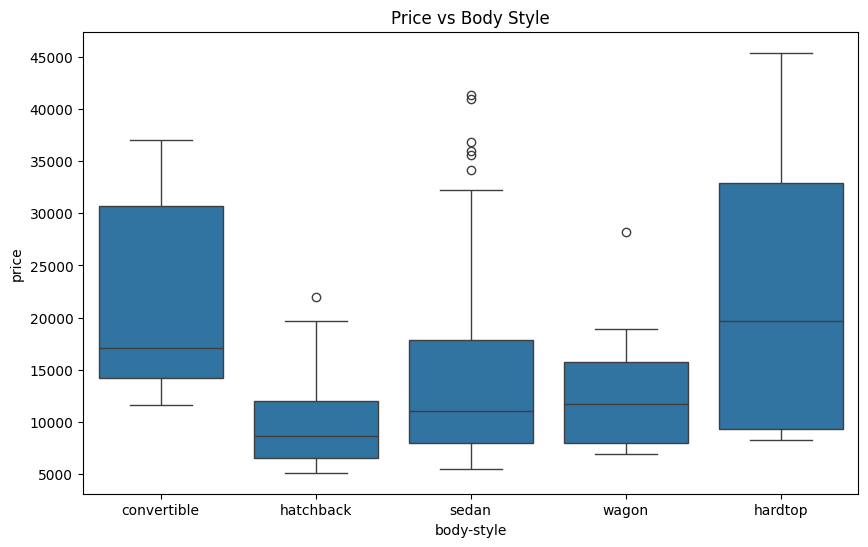

In [39]:
# Compare price across body styles
plt.figure(figsize=(10,6))

sns.boxplot(
    x="body-style",
    y="price",
    data=df
)

plt.title("Price vs Body Style")

plt.show()

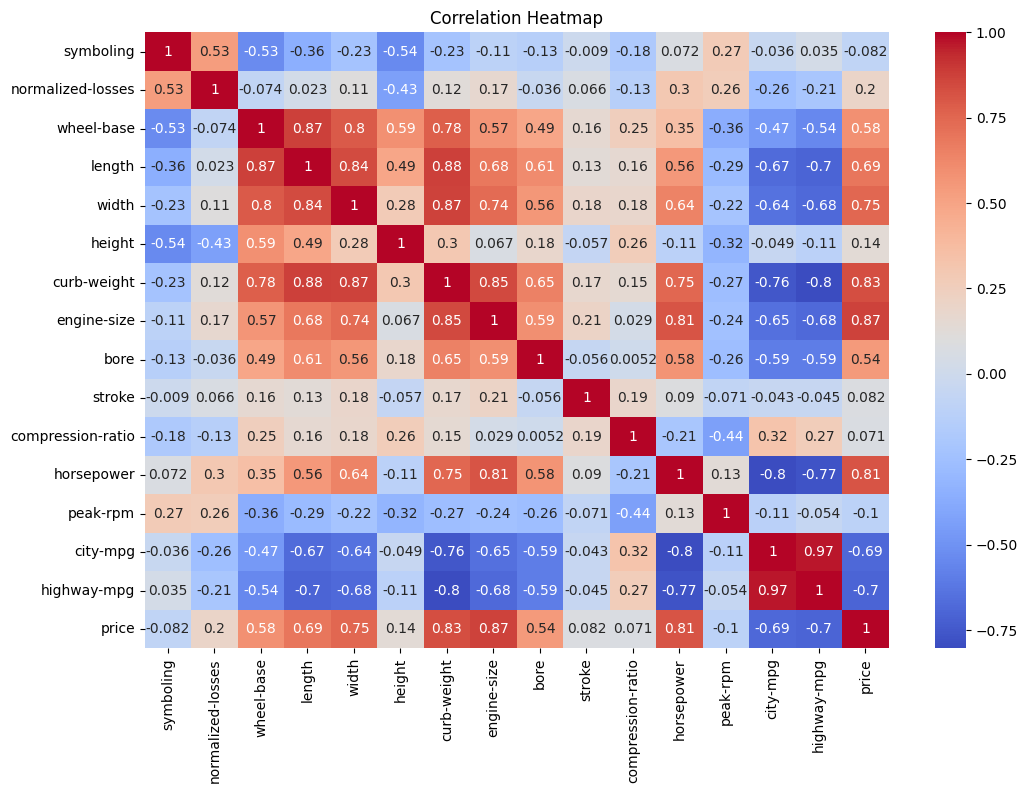

In [40]:
# Create correlation heatmap
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
#task2

In [52]:
# Replace missing indicators with NaN
df.replace("?", np.nan, inplace=True)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


In [42]:
# Check missing values
df.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [49]:
# Convert columns to numeric
df["normalized-losses"] = pd.to_numeric(df["normalized-losses"])
df["bore"] = pd.to_numeric(df["bore"])
df["stroke"] = pd.to_numeric(df["stroke"])
df["horsepower"] = pd.to_numeric(df["horsepower"])
df["peak-rpm"] = pd.to_numeric(df["peak-rpm"])
df["price"] = pd.to_numeric(df["price"])

In [47]:
# Fill missing numeric values using mean
df["normalized-losses"] = df["normalized-losses"].fillna(
    df["normalized-losses"].mean()
)

df["bore"] = df["bore"].fillna(
    df["bore"].mean()
)

df["stroke"] = df["stroke"].fillna(
    df["stroke"].mean()
)

df["horsepower"] = df["horsepower"].fillna(
    df["horsepower"].mean()
)

df["peak-rpm"] = df["peak-rpm"].fillna(
    df["peak-rpm"].mean()
)

In [ ]:
# Replace missing numerical values with column mean

In [48]:
# Fill missing categorical values using mode
df["num-of-doors"] = df["num-of-doors"].fillna(
    df["num-of-doors"].mode()[0]
)

# Remove rows with missing target values
df.dropna(subset=["price"], inplace=True)

# Verify missing values have been handled
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [53]:
# Create fuel consumption feature
df["city-L/100km"] = 235 / df["city-mpg"]

In [54]:
# Display new feature
df[["city-mpg", "city-L/100km"]].head()

,city-mpg,city-L/100km
0,21,11.190476
1,21,11.190476
2,19,12.368421
3,24,9.791667
4,18,13.055556


In [55]:
# Create horsepower categories
bins = [0, 100, 150, 300]

group_names = ["Low", "Medium", "High"]

In [56]:
# Apply horsepower binning
df["horsepower-binned"] = pd.cut(
    df["horsepower"],
    bins=bins,
    labels=group_names,
    include_lowest=True
)

In [57]:
# Display horsepower categories
df["horsepower-binned"].value_counts()

horsepower-binned
Low       109
Medium     62
High       30
Name: count, dtype: int64

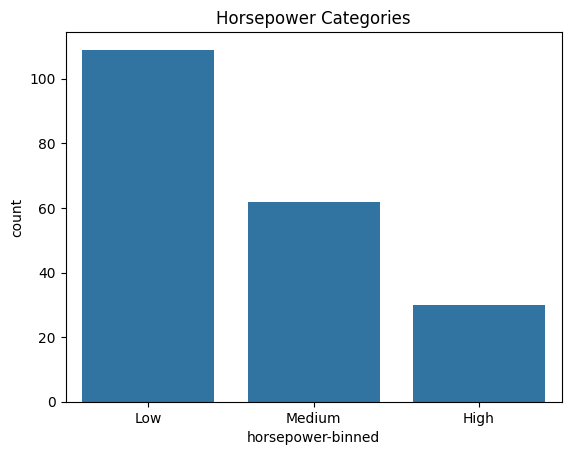

In [58]:
# Plot horsepower categories
sns.countplot(
    x="horsepower-binned",
    data=df
)

plt.title("Horsepower Categories")

plt.show()

In [59]:
# Normalize vehicle length
df["length-normalized"] = (
    df["length"] - df["length"].min()
) / (
    df["length"].max() - df["length"].min()
)

In [60]:
# Display normalized feature
df["length-normalized"].head()

0    0.413433
1    0.413433
2    0.449254
3    0.529851
4    0.529851
Name: length-normalized, dtype: float64

In [62]:
#TASK-3

In [63]:
# Select features and target variable
X = df[["horsepower", "engine-size"]]

y = df["price"]

In [65]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
# Train Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
# Generate predictions
y_pred = model.predict(X_test)

In [70]:
# Calculate evaluation metrics
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.7555654387380518
MAE: 3997.041824898603
MSE: 29905779.80028218


In [71]:
# Generate predictions
rf_pred = rf_model.predict(X_test)

In [72]:
# Calculate evaluation metrics
print("Random Forest R²:", r2_score(y_test, rf_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))

Random Forest R²: 0.9268293080707919
Random Forest MAE: 2153.8512526504664
Random Forest MSE: 8952198.041766157


In [73]:
# Create 70/30 train-test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [74]:
# Train model on 70/30 split
rf_model2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model2.fit(X_train2, y_train2)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [75]:
# Generate predictions
rf_pred2 = rf_model2.predict(X_test2)

print("70/30 Split Results")

print("R²:", r2_score(y_test2, rf_pred2))
print("MAE:", mean_absolute_error(y_test2, rf_pred2))
print("MSE:", mean_squared_error(y_test2, rf_pred2))

70/30 Split Results
R²: 0.9054064771281574
MAE: 2099.2823108407983
MSE: 8966676.891199613


In [76]:
# Compare model performance
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression (80/20)",
        "Random Forest (80/20)",
        "Random Forest (70/30)"
    ],
    "R²": [
        0.756,
        0.927,
        0.905
    ]
})

comparison

,Model,R²
0,Linear Regression (80/20),0.756
1,Random Forest (80/20),0.927
2,Random Forest (70/30),0.905


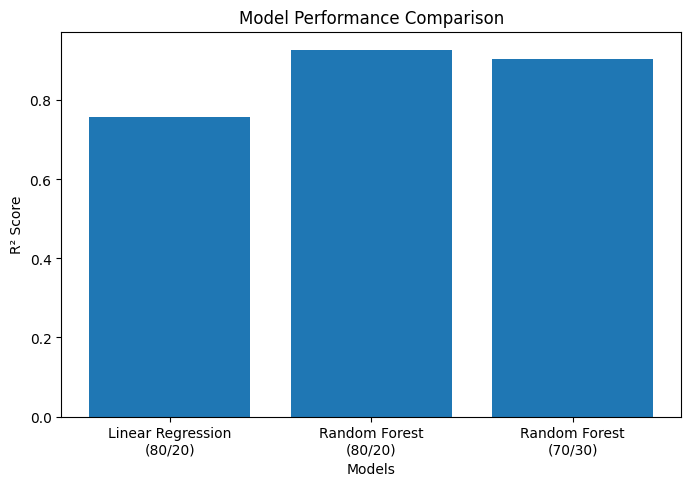

In [78]:
# Plot model comparison

models = [
    "Linear Regression\n(80/20)",
    "Random Forest\n(80/20)",
    "Random Forest\n(70/30)"
]

r2_scores = [
    0.756,
    0.927,
    0.905
]

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.show()

In [79]:
#TASK-4

In [81]:
# Create price categories
df["price-category"] = pd.qcut(
    df["price"],
    3,
    labels=["Low", "Medium", "High"]
)

In [82]:
# Display category counts
df["price-category"].value_counts()

price-category
Low       67
Medium    67
High      67
Name: count, dtype: int64

In [83]:
# Select features and target
X_class = df[["horsepower", "engine-size"]]

y_class = df["price-category"]

In [84]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

In [85]:
# Train Logistic Regression model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_c,
    y_train_c
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [86]:
# Predict price categories
y_pred_c = log_model.predict(X_test_c)

In [87]:
# Calculate classification accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test_c,
    y_pred_c
)

print("Accuracy:", accuracy)

Accuracy: 0.7073170731707317


In [88]:
# Generate confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_c,
    y_pred_c
)

print(cm)

[[12  0  2]
 [ 0 11  3]
 [ 4  3  6]]


In [89]:
# Generate classification report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_c,
        y_pred_c
    )
)

              precision    recall  f1-score   support

        High       0.75      0.86      0.80        14
         Low       0.79      0.79      0.79        14
      Medium       0.55      0.46      0.50        13

    accuracy                           0.71        41
   macro avg       0.69      0.70      0.70        41
weighted avg       0.70      0.71      0.70        41



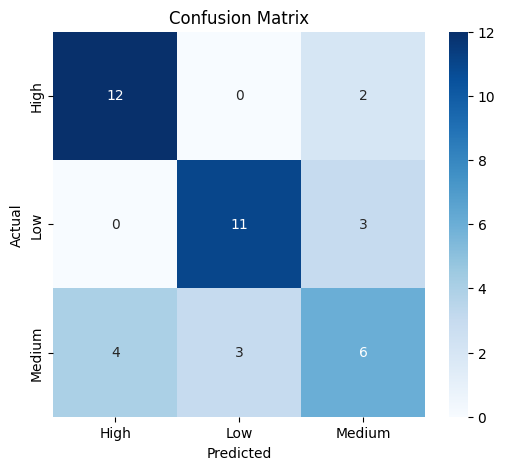

In [90]:
# Visualize confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["High", "Low", "Medium"],
    yticklabels=["High", "Low", "Medium"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

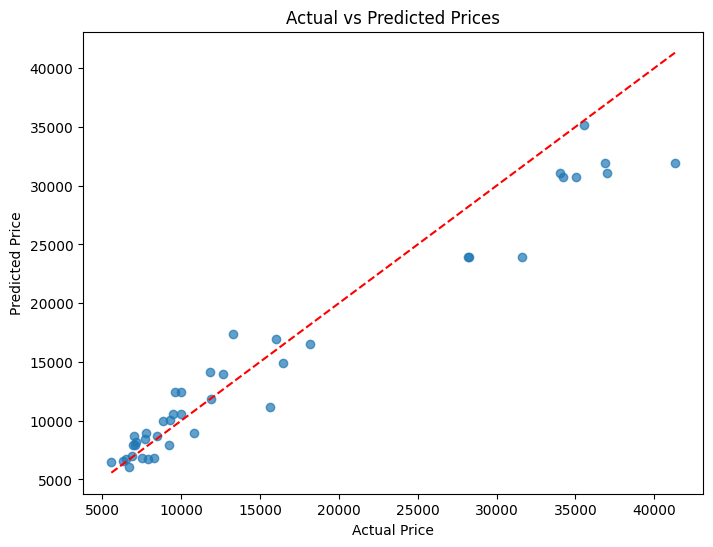

In [91]:
# Plot actual vs predicted prices

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.7
)

# Reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Actual vs Predicted Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

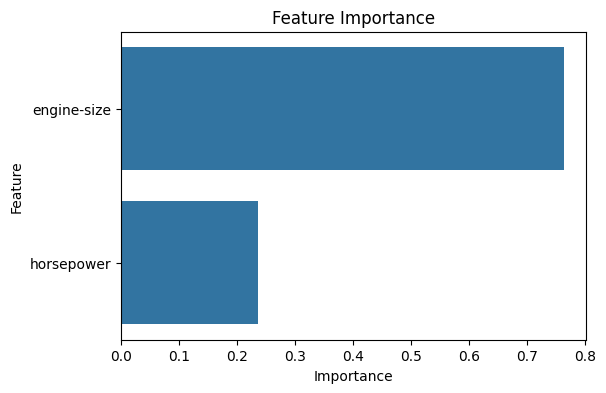

In [93]:
# Plot feature importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(6,4))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

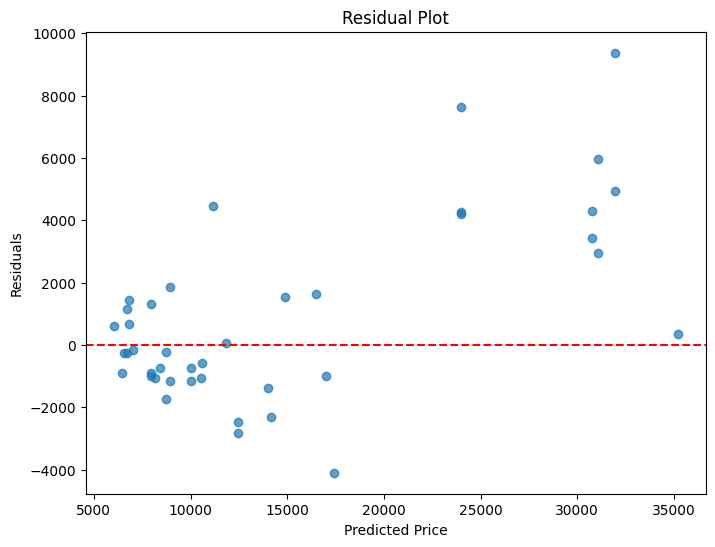

In [94]:
# Calculate residuals
residuals = y_test - rf_pred

plt.figure(figsize=(8,6))

plt.scatter(
    rf_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.show()